In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

from matplotlib.patches import ConnectionPatch

n_init = 10
save_to = "figures"

plt.rcParams.update({
    "text.usetex": True,
    "text.latex.preamble": r"\usepackage{sfmath}"
})

-1.9217444253548295
1.341771468527429


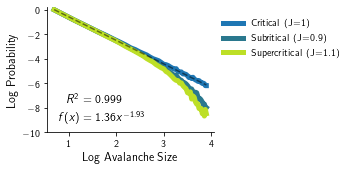

In [3]:
from scipy.stats import linregress

def get_xy(ps):
    x = np.load(f"data/power_x_{ps}.npy")
    y = np.load(f"data/power_y_{ps}.npy")
    
    y = y / y.max()

    x = np.log(x)
    y = np.log(y)
    
    return x, y

x, y = get_xy("1.0")
x09, y09 = get_xy("0.9")
x11, y11 = get_xy("1.1")

slope, intercept, r, p, se = linregress(x, y)
print(slope)
print(intercept)

cmap = plt.get_cmap("viridis")
fig, ax = plt.subplots(figsize = (3, 2.3))

ax.plot(x, y, linewidth = 5, color = "tab:blue", label = "Critical (J=1)")
ax.plot(x09, y09, linewidth = 5, color = cmap(0.4), label = "Subritical (J=0.9)")
ax.plot(x11, y11, linewidth = 5, color = cmap(0.9), label = "Supercritical (J=1.1)")

ax.set_xlabel("Log Avalanche Size", fontsize = 12)
ax.set_ylabel("Log Probability", fontsize = 12)

from sklearn.metrics import r2_score 
r2 = r2_score(y, x * slope + intercept)

ax.text(0.97, -7.5, f"$R^2={r2:.3f}$", fontfamily = "Arial", fontsize = 12)
ax.text(0.8, -9, "$f(x)=1.36x^{-1.93}$", fontfamily = "Arial", fontsize = 12)

ax.set_ylim([-10, 0.2])
ax.plot(
    np.linspace(np.min(x), np.max(x), 100),
    np.linspace(np.min(x), np.max(x), 100) * slope + intercept,
    color = "black",
    linestyle = "--",
    alpha = 0.5
)
sns.despine()
plt.legend(loc = "center left", bbox_to_anchor = (1.0, 0.75), frameon = False)
plt.savefig(os.path.join(save_to, "avalanche_power_log.png"), dpi = 300, transparent = True, bbox_inches = "tight")
plt.show()

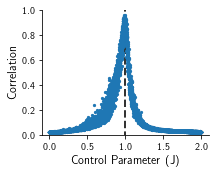

In [4]:
sigs = np.load("data/correlation_values.npy")

x = np.linspace(0, 2.7, sigs.shape[0])
rms = np.array([(10 - np.sqrt(np.mean((s - n_init) ** 2))) for s in sigs]) / n_init

inds = x <= 2.0
rms = rms[inds]
x = x[inds]

fig, ax = plt.subplots(figsize = (3, 2.3))
ax.set_ylim([-0, 1])
ax.scatter(x, rms, s = 5, zorder = 2)
ax.vlines([1.0], ymin = -0.2, ymax = 2, linewidth = 2.0, linestyle = "--", color = "black", zorder = 1, alpha = 0.8)

ax.set_xlabel("Control Parameter (J)", fontsize = 12)
ax.set_ylabel("Correlation", fontsize = 12)

sns.despine()
plt.savefig(os.path.join(save_to, "information_transfer.png"), dpi = 300, transparent = True, bbox_inches = "tight")
plt.show()

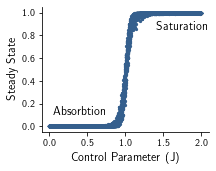

In [5]:
energy = np.load("data/energy.npy")
width = 20

x = np.linspace(0, 2.7, energy.shape[0])
inds = x <= 2.0
energy = energy[inds] / width
x = x[inds]

cmap = plt.get_cmap("viridis")
fig, ax = plt.subplots(figsize = (3, 2.3))
ax.scatter(x, energy.mean(axis = 1), s = 5, color = cmap(0.3))
sns.despine()

ax.set_xlabel("Control Parameter (J)", fontsize = 12)
ax.set_ylabel("Steady State", fontsize = 12)

ax.text(0.05, 0.1, "Absorbtion", fontfamily = "Arial", fontsize = 12)
ax.text(1.4, 0.85, "Saturation", fontfamily = "Arial", fontsize = 12)

plt.savefig(os.path.join(save_to, "energy.png"), dpi = 300, transparent = True, bbox_inches = "tight")
plt.show()